# LightGBM Benchmarking Notebook — Turkey STLF
**Target:** `actual_load` (MW) at horizon **t+24h**  
**Train:** 2018–2022 | **Val:** 2023 | **Test:** 2024–2025-03  
**Project:** Ramadan-Aware STLF Benchmarking (Capstone — EUI 2026)

---
### Notebook Structure
1. Setup & Imports  
2. Data Load & Regime Labelling  
3. Feature Engineering  
4. Train / Val / Test Split  
5. Metric Helpers (MAE, RMSE, MAPE, MASE + DM test)  
6. Ablation A — Ramadan-indicator inclusion (Base vs Hijri, default params)  
7. Ablation B — Heatwave interaction features  
8. Optuna Hyperparameter Tuning (Hijri + HW-Aware)  
9. Final Tuned Model  
10. Full Evaluation & Visualisation  
11. Regime-Conditional Error Analysis (4-regime: Normal / Ramadan / Heatwave / Compound)  
12. Diebold-Mariano Statistical Tests  
13. Save Predictions — Benchmarking Parquet  
14. Feature Importance

---
## Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import lightgbm as lgb
import optuna
import joblib
from pathlib import Path
from itertools import combinations
from scipy import stats

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Colour palette ────────────────────────────────────────────────────────
C_BLUE   = '#64b5f6'
C_ORANGE = '#ffb74d'
C_GREEN  = '#81c784'
C_RED    = '#e57373'
C_PURPLE = '#ba68c8'
C_TEAL   = '#4db6ac'

REGIME_COLORS = {
    'Normal':   C_BLUE,
    'Ramadan':  C_ORANGE,
    'Heatwave': C_RED,
    'Compound': C_PURPLE,   # Ramadan AND T_max >= 35 C
}

SEED = 42
print('Libraries loaded.')

Libraries loaded.


---
## Data Load & Regime Labelling

In [2]:
ROOT_DIR  = Path().resolve().parents[0]
CSV_PATH  = ROOT_DIR / 'data' / 'processed' / 'final_training_set_v1.csv'
MODEL_DIR = ROOT_DIR / 'models'
PRED_DIR  = ROOT_DIR / 'predictions'
MODEL_DIR.mkdir(exist_ok=True, parents=True)
PRED_DIR.mkdir(exist_ok=True, parents=True)

df = pd.read_csv(CSV_PATH)
df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
df = df.set_index('timestamp').sort_index()

# ── Heatwave: T_max >= 95th-pct AND >= 3 consecutive days (proposal §Table 3) ──
daily_max = df.groupby(df.index.date)['temp_c'].max()
HW_THRESH = daily_max.quantile(0.95)
exceeds   = daily_max >= HW_THRESH
dates     = sorted(exceeds.index)
hw_days   = set()
for i, d in enumerate(dates):
    if exceeds[d] and i >= 2 and exceeds[dates[i-1]] and exceeds[dates[i-2]]:
        hw_days.update([dates[i-2], dates[i-1], d])
    elif exceeds[d] and i >= 1 and exceeds[dates[i-1]] and d in hw_days:
        hw_days.add(d)

df['is_heatwave'] = [int(ts.date() in hw_days) for ts in df.index]

# ── Four-regime labelling ─────────────────────────────────────────────────
def regime(row):
    if row['is_ramadan'] and row['is_heatwave']: return 'Compound'
    if row['is_ramadan']:                         return 'Ramadan'
    if row['is_heatwave']:                        return 'Heatwave'
    return 'Normal'

df['regime'] = df.apply(regime, axis=1)

print(f'Loaded   : {len(df):,} rows | {df.index[0].date()} -> {df.index[-1].date()}')
print(f'HW thresh: {HW_THRESH:.2f} C')
print(f'Regime counts:\n{df["regime"].value_counts().to_string()}')

Loaded   : 70,125 rows | 2018-01-01 -> 2025-12-31
HW thresh: 31.75 C
Regime counts:
regime
Normal      61653
Ramadan      5688
Heatwave     2784


---
## Feature Engineering

All features are constructed so they are **available at forecast time** (t+24h horizon).  
Weather covariates use ERA5 reanalysis values at t+24 (treated as known forecasts).  
Lag features use only information up to time t.

In [3]:
# ── Cyclical calendar encoding ────────────────────────────────────────────
df['hour_sin']  = np.sin(2 * np.pi * df.index.hour / 24)
df['hour_cos']  = np.cos(2 * np.pi * df.index.hour / 24)
df['dow_sin']   = np.sin(2 * np.pi * df.index.dayofweek / 7)
df['dow_cos']   = np.cos(2 * np.pi * df.index.dayofweek / 7)
df['month_sin'] = np.sin(2 * np.pi * df.index.month / 12)
df['month_cos'] = np.cos(2 * np.pi * df.index.month / 12)

# ── Nonlinear temperature features ───────────────────────────────────────
df['temp_sq']       = df['temp_c'] ** 2
df['temp_above_hw'] = (df['temp_c'] - HW_THRESH).clip(lower=0)
df['is_weekend']    = (df.index.dayofweek >= 5).astype(int)

# ── Ramadan x time-of-day (iftar ~UTC17, suhoor ~UTC01) ──────────────────
df['ramadan_x_hour_sin'] = df['is_ramadan'] * df['hour_sin']
df['ramadan_x_hour_cos'] = df['is_ramadan'] * df['hour_cos']
df['ramadan_x_weekend']  = df['is_ramadan'] * df['is_weekend']

# ── Heatwave interaction features (Ablation B) ────────────────────────────
df['heatwave_x_temp']     = df['is_heatwave'] * df['temp_c']
df['heatwave_x_hour_sin'] = df['is_heatwave'] * df['hour_sin']  # peak AC timing
df['heatwave_x_hour_cos'] = df['is_heatwave'] * df['hour_cos']

# ── Additional lag features ───────────────────────────────────────────────
df['load_lag_48h']  = df['actual_load'].shift(48)    # 2-day same-hour
df['load_lag_336h'] = df['actual_load'].shift(336)   # 2-week same-hour

print('Feature engineering complete.')
print(f'Total columns: {len(df.columns)}')

Feature engineering complete.
Total columns: 36


---
## Train / Val / Test Split

In [4]:
# ── Feature sets ──────────────────────────────────────────────────────────
# Ablation A control — NO Hijri
BASE_FEATURES = [
    'temp_c', 'dewpoint_c', 'wind_speed', 'solar_rad',
    'temp_sq', 'temp_above_hw',
    'hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'month_sin', 'month_cos',
    'hour', 'day_of_week', 'month',
    'is_weekend',
    'load_lag_24h', 'load_lag_48h', 'load_lag_168h', 'load_lag_336h',
    'load_rolling_mean_24h', 'load_rolling_std_24h',
    'load_rolling_mean_168h', 'load_rolling_std_168h',
    'is_heatwave', 'heatwave_x_temp',
]

# Ablation A treatment — +Hijri
HIJRI_FEATURES = [
    'is_ramadan', 'is_eid', 'day_of_ramadan',
    'ramadan_x_hour_sin', 'ramadan_x_hour_cos', 'ramadan_x_weekend',
]

# Ablation B — heatwave interaction (added on top of ALL_FEATURES)
HW_INTERACTION_FEATURES = [
    'heatwave_x_hour_sin', 'heatwave_x_hour_cos',
]

ALL_FEATURES  = BASE_FEATURES + HIJRI_FEATURES
FULL_FEATURES = ALL_FEATURES  + HW_INTERACTION_FEATURES

TARGET = 'actual_load'

# ── Strict chronological splits (no temporal leakage) ─────────────────────
TRAIN = df.loc['2018':'2022'].dropna(subset=FULL_FEATURES + [TARGET])
VAL   = df.loc['2023'].dropna(subset=FULL_FEATURES + [TARGET])
TEST  = df.loc['2024':'2025-03'].dropna(subset=FULL_FEATURES + [TARGET])

X_train, y_train = TRAIN[FULL_FEATURES], TRAIN[TARGET]
X_val,   y_val   = VAL[FULL_FEATURES],   VAL[TARGET]
X_test,  y_test  = TEST[FULL_FEATURES],  TEST[TARGET]

print(f'Train : {len(X_train):,} rows ({TRAIN.index[0].date()} -> {TRAIN.index[-1].date()})')
print(f'Val   : {len(X_val):,}  rows ({VAL.index[0].date()}   -> {VAL.index[-1].date()})')
print(f'Test  : {len(X_test):,} rows ({TEST.index[0].date()}  -> {TEST.index[-1].date()})')
print(f'\nBase features    : {len(BASE_FEATURES)}')
print(f'Hijri features   : {len(HIJRI_FEATURES)}')
print(f'HW interaction   : {len(HW_INTERACTION_FEATURES)}')
print(f'Total (full)     : {len(FULL_FEATURES)}')

Train : 43,488 rows (2018-01-15 -> 2022-12-31)
Val   : 8,760  rows (2023-01-01   -> 2023-12-31)
Test  : 10,944 rows (2024-01-01  -> 2025-03-31)

Base features    : 26
Hijri features   : 6
HW interaction   : 2
Total (full)     : 34


---
## Metric Helpers

In [5]:
# ── Scalar metrics ────────────────────────────────────────────────────────
def mape(y_true, y_pred):
    """MAPE — excludes zero actuals."""
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def mase(y_true, y_pred, y_train, period=168):
    """MASE vs seasonal-naive lag-168 (weekly)."""
    y_train = np.asarray(y_train)
    scale   = np.mean(np.abs(y_train[period:] - y_train[:-period]))
    return mean_absolute_error(y_true, y_pred) / scale

def evaluate(y_true, y_pred, y_train, label=''):
    """Print and return scalar metric dict."""
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mp   = mape(y_true, y_pred)
    ms   = mase(y_true, y_pred, y_train)
    if label:
        print(f'  [{label}]')
    print(f'  MAE  : {mae:>9.2f} MW')
    print(f'  RMSE : {rmse:>9.2f} MW')
    print(f'  MAPE : {mp:>9.4f} %')
    print(f'  MASE : {ms:>9.4f}')
    return {'label': label, 'MAE': mae, 'RMSE': rmse, 'MAPE': mp, 'MASE': ms}

# ── 4-regime stratified evaluation (proposal Table 3) ─────────────────────
REGIMES = ['Normal', 'Ramadan', 'Heatwave', 'Compound']

def regime_evaluate(y_true, y_pred, regimes, y_train):
    """Return per-regime metric DataFrame across all 4 regimes."""
    rows = []
    for r in REGIMES:
        mask = regimes == r
        if mask.sum() == 0:
            rows.append({'Regime': r, 'N': 0,
                         'MAE': np.nan, 'RMSE': np.nan,
                         'MAPE': np.nan, 'MASE': np.nan})
            continue
        yt, yp = y_true[mask], y_pred[mask]
        rows.append({
            'Regime': r, 'N': int(mask.sum()),
            'MAE' : round(mean_absolute_error(yt, yp), 2),
            'RMSE': round(np.sqrt(mean_squared_error(yt, yp)), 2),
            'MAPE': round(mape(yt, yp), 4),
            'MASE': round(mase(yt, yp, y_train), 4),
        })
    return pd.DataFrame(rows).set_index('Regime')

# ── Diebold-Mariano test (Newey-West HAC, proposal §5) ────────────────────
def dm_test(y_true, pred_a, pred_b, h=24, crit='MAE'):
    """
    Two-sided DM test: H0 = equal predictive accuracy.
    Newey-West HAC SE with bandwidth = h.
    Returns (DM statistic, p-value).
    """
    if crit == 'MAE':
        e1 = np.abs(y_true - pred_a)
        e2 = np.abs(y_true - pred_b)
    else:
        e1 = (y_true - pred_a) ** 2
        e2 = (y_true - pred_b) ** 2
    d     = e1 - e2
    T     = len(d)
    d_bar = d.mean()
    nw_var = np.mean((d - d_bar) ** 2)
    for lag in range(1, h + 1):
        w        = 1 - lag / (h + 1)
        gamma_l  = np.mean((d[lag:] - d_bar) * (d[:-lag] - d_bar))
        nw_var  += 2 * w * gamma_l
    se      = np.sqrt(max(nw_var, 1e-12) / T)
    dm_stat = d_bar / se
    p_val   = 2 * (1 - stats.norm.cdf(abs(dm_stat)))
    return float(dm_stat), float(p_val)

def dm_table(y_true, predictions_dict, h=24):
    """
    Pairwise DM tests (MAE loss) with Holm-Bonferroni correction.
    predictions_dict: {model_name: pred_array}
    """
    keys = list(predictions_dict.keys())
    rows, raw_pvals = [], []
    for a, b in combinations(keys, 2):
        dm, p = dm_test(y_true, predictions_dict[a], predictions_dict[b], h=h)
        rows.append({'Model A': a, 'Model B': b,
                     'DM stat': round(dm, 3), 'p-value (raw)': round(p, 4)})
        raw_pvals.append(p)
    # Holm-Bonferroni
    n     = len(raw_pvals)
    order = np.argsort(raw_pvals)
    corr  = np.array(raw_pvals, dtype=float)
    for rank, idx in enumerate(order):
        corr[idx] = min(1.0, raw_pvals[idx] * (n - rank))
    for i, row in enumerate(rows):
        row['p-value (HB)']       = round(corr[i], 4)
        row['Reject H0 (a=0.05)'] = bool(corr[i] < 0.05)
    return pd.DataFrame(rows)

print('Metric helpers defined.')

Metric helpers defined.


---
## Ablation A — Ramadan-Indicator Inclusion
Control: `BASE_FEATURES` (no Hijri). Treatment: `ALL_FEATURES` (+Hijri).  
Identical `DEFAULT_PARAMS` — only the feature set differs.  
This directly answers the capstone's primary ablation question.

In [6]:
DEFAULT_PARAMS = {
    'objective':         'regression',
    'metric':            'mae',
    'boosting_type':     'gbdt',
    'n_estimators':      2000,
    'learning_rate':     0.05,
    'num_leaves':        63,
    'max_depth':         8,
    'min_child_samples': 20,
    'feature_fraction':  0.8,
    'bagging_fraction':  0.8,
    'bagging_freq':      1,
    'lambda_l1':         0.1,
    'lambda_l2':         5.0,
    'verbose':           -1,
    'random_state':      SEED,
    'n_jobs':            -1,
}

# ── A1: Base (no Hijri) ───────────────────────────────────────────────────
model_base = lgb.LGBMRegressor(**DEFAULT_PARAMS)
model_base.fit(
    X_train[BASE_FEATURES], y_train,
    eval_set=[(X_val[BASE_FEATURES], y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
pred_base_val  = model_base.predict(X_val[BASE_FEATURES])
pred_base_test = model_base.predict(X_test[BASE_FEATURES])
joblib.dump(model_base, MODEL_DIR / 'lgbm_ablation_A_base.pkl')

print('\n=== A1: Base (no Hijri) — Validation ===')
metrics_base_val  = evaluate(y_val.values,  pred_base_val,  y_train, 'Val')
print('\n=== A1: Base (no Hijri) — Test ===')
metrics_base_test = evaluate(y_test.values, pred_base_test, y_train, 'Test')

# ── A2: Hijri-Aware (default params) ─────────────────────────────────────
model_hijri = lgb.LGBMRegressor(**DEFAULT_PARAMS)
model_hijri.fit(
    X_train[ALL_FEATURES], y_train,
    eval_set=[(X_val[ALL_FEATURES], y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
pred_hijri_val  = model_hijri.predict(X_val[ALL_FEATURES])
pred_hijri_test = model_hijri.predict(X_test[ALL_FEATURES])
joblib.dump(model_hijri, MODEL_DIR / 'lgbm_ablation_A_hijri.pkl')

print('\n=== A2: Hijri-Aware (default) — Validation ===')
metrics_hijri_val  = evaluate(y_val.values,  pred_hijri_val,  y_train, 'Val')
print('\n=== A2: Hijri-Aware (default) — Test ===')
metrics_hijri_test = evaluate(y_test.values, pred_hijri_test, y_train, 'Test')


=== A1: Base (no Hijri) — Validation ===
  [Val]
  MAE  :    570.58 MW
  RMSE :    860.39 MW
  MAPE :    1.5625 %
  MASE :    0.3439

=== A1: Base (no Hijri) — Test ===
  [Test]
  MAE  :    811.23 MW
  RMSE :   1207.64 MW
  MAPE :    2.0480 %
  MASE :    0.4890

=== A2: Hijri-Aware (default) — Validation ===
  [Val]
  MAE  :    565.84 MW
  RMSE :    861.68 MW
  MAPE :    1.5507 %
  MASE :    0.3411

=== A2: Hijri-Aware (default) — Test ===
  [Test]
  MAE  :    800.01 MW
  RMSE :   1181.42 MW
  MAPE :    2.0107 %
  MASE :    0.4822


---
## Ablation B — Heatwave Interaction Features
Tests whether encoding `heatwave × hour_sin/cos` (peak AC timing)  
adds value on top of Hijri-Aware features. Same default params.  
Particularly diagnostic for the **Compound** regime (Ramadan ∧ T_max ≥ 35°C).

In [7]:
model_hw = lgb.LGBMRegressor(**DEFAULT_PARAMS)
model_hw.fit(
    X_train[FULL_FEATURES], y_train,
    eval_set=[(X_val[FULL_FEATURES], y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)
pred_hw_val  = model_hw.predict(X_val[FULL_FEATURES])
pred_hw_test = model_hw.predict(X_test[FULL_FEATURES])
joblib.dump(model_hw, MODEL_DIR / 'lgbm_ablation_B_hw.pkl')

print('\n=== B: Hijri + HW-Interaction (default) — Validation ===')
metrics_hw_val  = evaluate(y_val.values,  pred_hw_val,  y_train, 'Val')
print('\n=== B: Hijri + HW-Interaction (default) — Test ===')
metrics_hw_test = evaluate(y_test.values, pred_hw_test, y_train, 'Test')

print('\n=== Ablation A vs B — Test MAE delta ===')
print(f'  A1 Base        : {metrics_base_test["MAE"]:.2f} MW')
print(f'  A2 Hijri       : {metrics_hijri_test["MAE"]:.2f} MW  (delta vs A1 {metrics_hijri_test["MAE"]-metrics_base_test["MAE"]:+.2f})')
print(f'  B  HW-inter    : {metrics_hw_test["MAE"]:.2f} MW  (delta vs A2 {metrics_hw_test["MAE"]-metrics_hijri_test["MAE"]:+.2f})')


=== B: Hijri + HW-Interaction (default) — Validation ===
  [Val]
  MAE  :    567.57 MW
  RMSE :    853.52 MW
  MAPE :    1.5529 %
  MASE :    0.3421

=== B: Hijri + HW-Interaction (default) — Test ===
  [Test]
  MAE  :    804.82 MW
  RMSE :   1186.70 MW
  MAPE :    2.0170 %
  MASE :    0.4851

=== Ablation A vs B — Test MAE delta ===
  A1 Base        : 811.23 MW
  A2 Hijri       : 800.01 MW  (delta vs A1 -11.22)
  B  HW-inter    : 804.82 MW  (delta vs A2 +4.82)


---
## Optuna Hyperparameter Tuning
50-trial TPE search on validation MAE — matches proposal §4.2.

In [8]:
def objective(trial):
    params = {
        'objective':         'regression',
        'metric':            'mae',
        'boosting_type':     'gbdt',
        'verbose':           -1,
        'random_state':      SEED,
        'n_jobs':            -1,
        'n_estimators':      2000,
        'learning_rate':     trial.suggest_float('learning_rate',  0.01,  0.1,  log=True),
        'num_leaves':        trial.suggest_int('num_leaves',       31,    255),
        'max_depth':         trial.suggest_int('max_depth',        4,     12),
        'min_child_samples': trial.suggest_int('min_child_samples',10,    100),
        'feature_fraction':  trial.suggest_float('feature_fraction',0.5,  1.0),
        'bagging_fraction':  trial.suggest_float('bagging_fraction',0.5,  1.0),
        'bagging_freq':      1,
        'lambda_l1':         trial.suggest_float('lambda_l1',      1e-4,  10.0, log=True),
        'lambda_l2':         trial.suggest_float('lambda_l2',      1e-4,  10.0, log=True),
        'min_split_gain':    trial.suggest_float('min_split_gain', 0.0,   1.0),
    }
    model = lgb.LGBMRegressor(**params)
    model.fit(
        X_train[FULL_FEATURES], y_train,
        eval_set=[(X_val[FULL_FEATURES], y_val)],
        callbacks=[
            lgb.early_stopping(50, verbose=False),
            lgb.log_evaluation(period=-1),
        ]
    )
    return mean_absolute_error(y_val, model.predict(X_val[FULL_FEATURES]))

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f'\nBest Val MAE : {study.best_value:.2f} MW')
print('Best params  :')
for k, v in study.best_params.items():
    print(f'  {k:<25}: {v}')

Best trial: 46. Best value: 543.852: 100%|█████████████████████████████████████████████| 50/50 [05:18<00:00,  6.37s/it]


Best Val MAE : 543.85 MW
Best params  :
  learning_rate            : 0.02117027552717486
  num_leaves               : 244
  max_depth                : 9
  min_child_samples        : 65
  feature_fraction         : 0.5977002508439575
  bagging_fraction         : 0.505915178985751
  lambda_l1                : 0.0001511593977192922
  lambda_l2                : 0.011215909286741623
  min_split_gain           : 0.9467962969679371


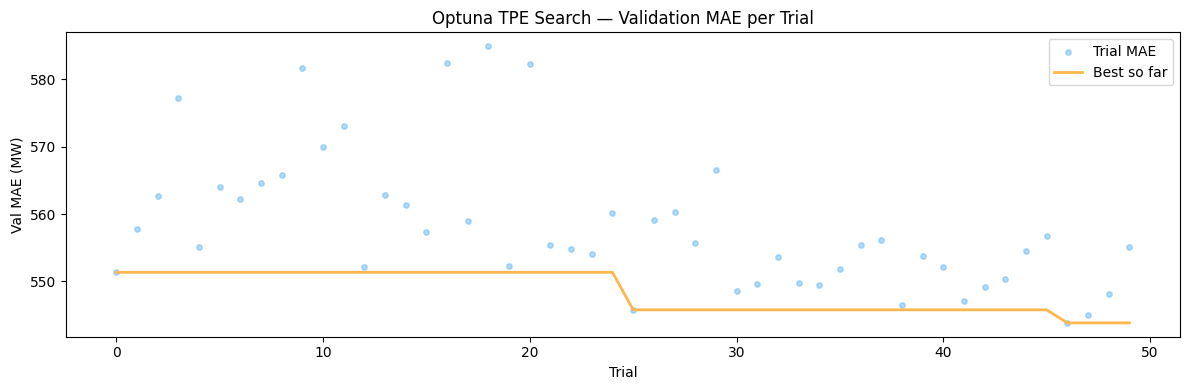

In [9]:
# ── Optuna convergence plot ───────────────────────────────────────────────
trial_vals  = [t.value for t in study.trials]
best_so_far = pd.Series(trial_vals).cummin()

fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(range(len(trial_vals)), trial_vals, s=15, alpha=0.5, color=C_BLUE, label='Trial MAE')
ax.plot(best_so_far.values, color=C_ORANGE, lw=2, label='Best so far')
ax.set_title('Optuna TPE Search — Validation MAE per Trial')
ax.set_xlabel('Trial')
ax.set_ylabel('Val MAE (MW)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Final Tuned Model

In [10]:
BEST_PARAMS = {
    'objective':     'regression',
    'metric':        'mae',
    'boosting_type': 'gbdt',
    'verbose':       -1,
    'random_state':  SEED,
    'n_jobs':        -1,
    'n_estimators':  3000,
    **study.best_params,
}

model_tuned = lgb.LGBMRegressor(**BEST_PARAMS)
model_tuned.fit(
    X_train[FULL_FEATURES], y_train,
    eval_set=[(X_val[FULL_FEATURES], y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False)]
)
joblib.dump(model_tuned, MODEL_DIR / 'lgbm_tuned_hijri_hw.pkl')

pred_tuned_val  = model_tuned.predict(X_val[FULL_FEATURES])
pred_tuned_test = model_tuned.predict(X_test[FULL_FEATURES])

print('\n=== TUNED (Hijri + HW-Interaction) — Validation ===')
metrics_tuned_val  = evaluate(y_val.values,  pred_tuned_val,  y_train, 'Val')
print('\n=== TUNED (Hijri + HW-Interaction) — Test ===')
metrics_tuned_test = evaluate(y_test.values, pred_tuned_test, y_train, 'Test')
print(f'\nModel saved -> {MODEL_DIR / "lgbm_tuned_hijri_hw.pkl"}')


=== TUNED (Hijri + HW-Interaction) — Validation ===
  [Val]
  MAE  :    556.80 MW
  RMSE :    828.28 MW
  MAPE :    1.5247 %
  MASE :    0.3356

=== TUNED (Hijri + HW-Interaction) — Test ===
  [Test]
  MAE  :    810.27 MW
  RMSE :   1202.08 MW
  MAPE :    2.0281 %
  MASE :    0.4884

Model saved -> C:\Users\dr_sh\OneDrive\Desktop\ElectricityLoadForcasting\models\lgbm_tuned_hijri_hw.pkl


---
## Full Evaluation & Visualisation

In [11]:
# ── Aggregate model comparison table ─────────────────────────────────────
comparison = pd.DataFrame([
    {**metrics_base_test,  'Model': 'LightGBM — A1: No Hijri (default)'},
    {**metrics_hijri_test, 'Model': 'LightGBM — A2: Hijri (default)'},
    {**metrics_hw_test,    'Model': 'LightGBM — B:  Hijri + HW-inter (default)'},
    {**metrics_tuned_test, 'Model': 'LightGBM — Tuned (Hijri + HW-inter, Optuna)'},
]).set_index('Model')[['MAE','RMSE','MAPE','MASE']]

print('=== Test Set — Aggregate Model Comparison ===')
print(comparison.round(4).to_string())

best = comparison.idxmin()
print('\nBest per metric:')
for m, name in best.items():
    print(f'  {m}: {name}  ({comparison.loc[name, m]:.4f})')

=== Test Set — Aggregate Model Comparison ===
                                                  MAE       RMSE    MAPE    MASE
Model                                                                           
LightGBM — A1: No Hijri (default)            811.2310  1207.6385  2.0480  0.4890
LightGBM — A2: Hijri (default)               800.0069  1181.4155  2.0107  0.4822
LightGBM — B:  Hijri + HW-inter (default)    804.8247  1186.6958  2.0170  0.4851
LightGBM — Tuned (Hijri + HW-inter, Optuna)  810.2674  1202.0773  2.0281  0.4884

Best per metric:
  MAE: LightGBM — A2: Hijri (default)  (800.0069)
  RMSE: LightGBM — A2: Hijri (default)  (1181.4155)
  MAPE: LightGBM — A2: Hijri (default)  (2.0107)
  MASE: LightGBM — A2: Hijri (default)  (0.4822)


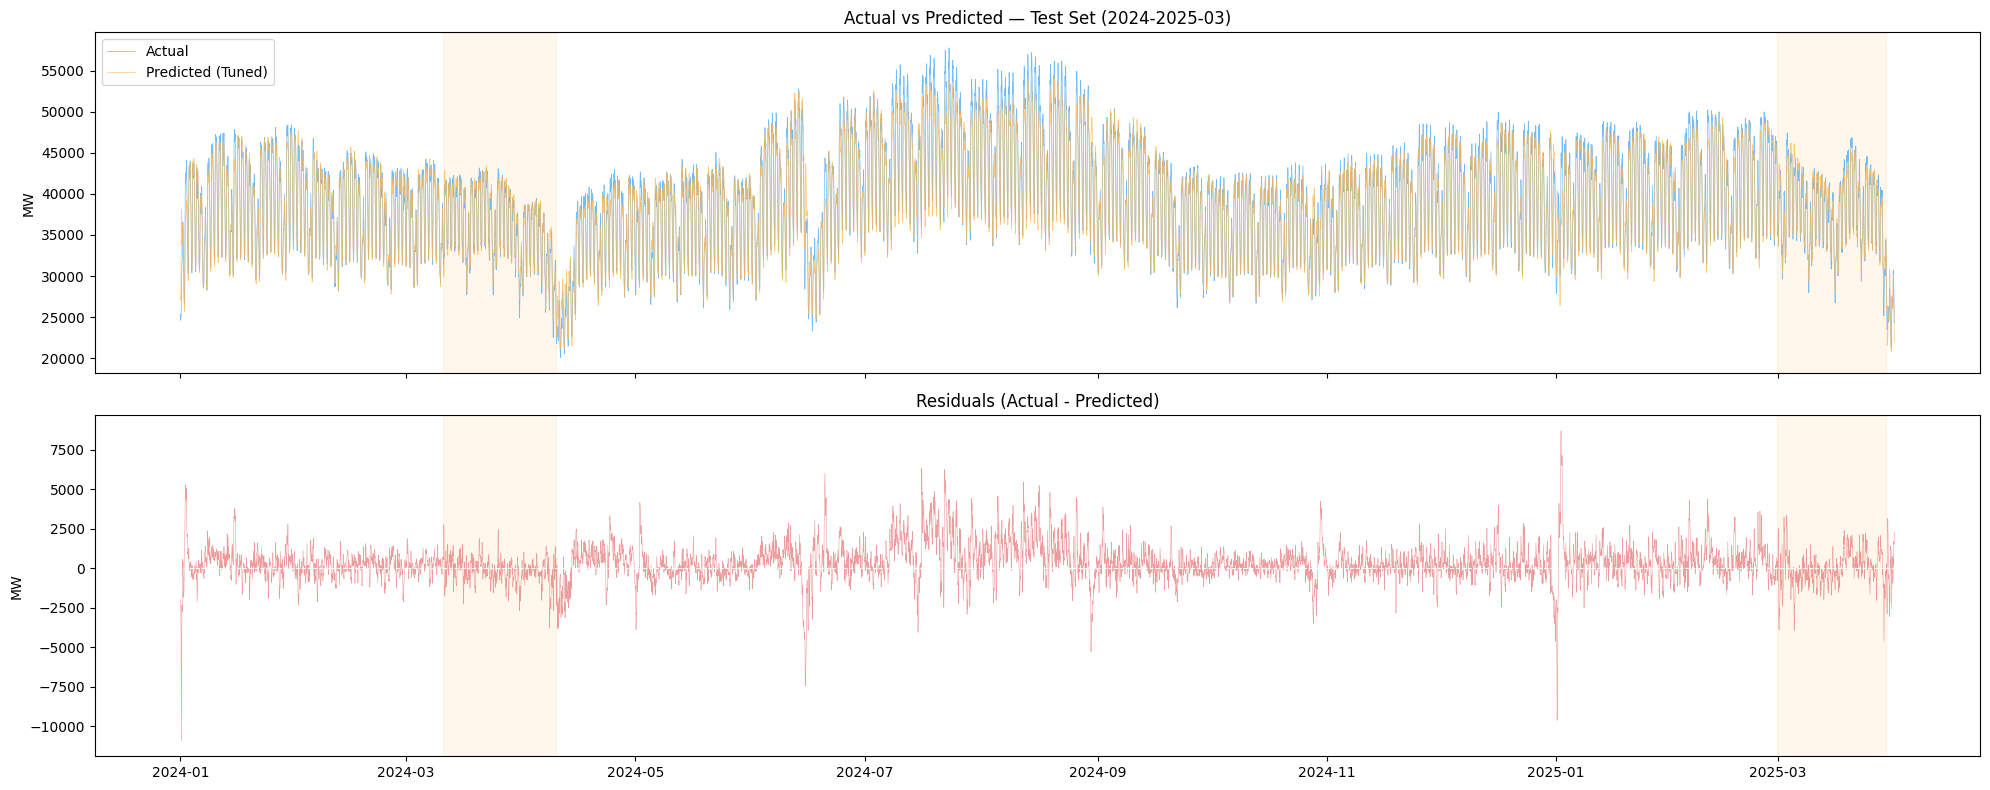

In [12]:
# ── Actual vs Predicted — full test set ──────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(20, 8), sharex=True)

axes[0].plot(TEST.index, y_test.values,   color=C_BLUE,   lw=0.5, alpha=0.9,  label='Actual')
axes[0].plot(TEST.index, pred_tuned_test, color=C_ORANGE, lw=0.5, alpha=0.75, label='Predicted (Tuned)')
axes[0].set_title('Actual vs Predicted — Test Set (2024-2025-03)')
axes[0].set_ylabel('MW')
axes[0].legend()

residuals = y_test.values - pred_tuned_test
axes[1].plot(TEST.index, residuals, color=C_RED, lw=0.4, alpha=0.7)
axes[1].axhline(0, color='white', lw=0.8, ls='--')
axes[1].set_title('Residuals (Actual - Predicted)')
axes[1].set_ylabel('MW')

# Shade Ramadan and Compound windows
for regime_name, color in [('Ramadan', C_ORANGE), ('Compound', C_PURPLE)]:
    in_window = False; w_start = None
    for ts, val in TEST['regime'].items():
        if val == regime_name and not in_window:
            w_start = ts; in_window = True
        elif val != regime_name and in_window:
            for ax in axes:
                ax.axvspan(w_start, ts, alpha=0.10, color=color, label=f'_{regime_name}')
            in_window = False

plt.tight_layout()
plt.show()

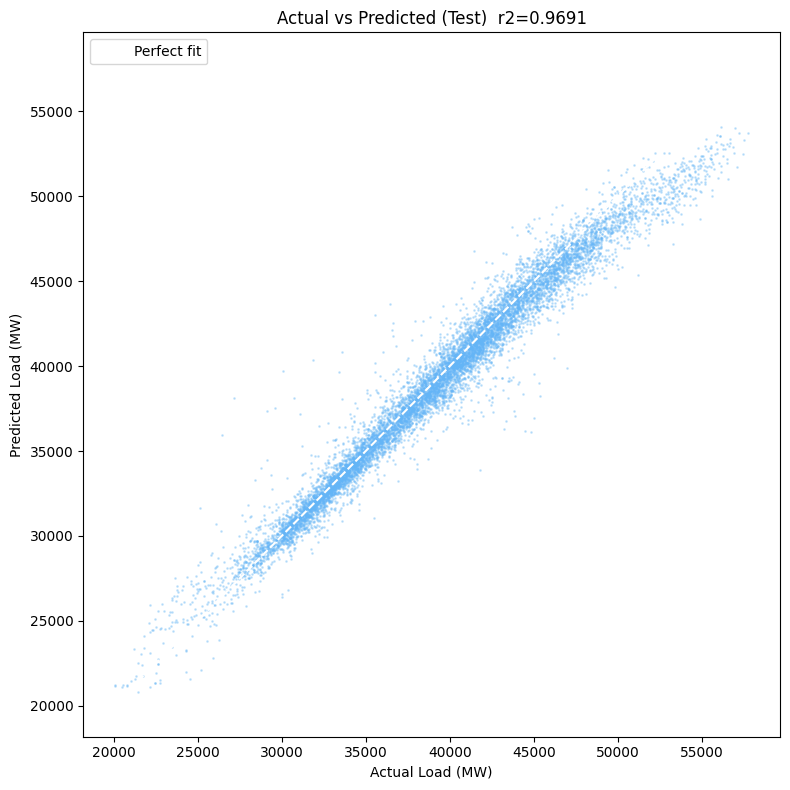

In [13]:
# ── Scatter: Actual vs Predicted ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test.values, pred_tuned_test, s=1, alpha=0.3, color=C_BLUE, rasterized=True)
lims = [min(y_test.min(), pred_tuned_test.min()),
        max(y_test.max(), pred_tuned_test.max())]
ax.plot(lims, lims, color='white', lw=1.5, ls='--', label='Perfect fit')
r, _ = stats.pearsonr(y_test.values, pred_tuned_test)
ax.set_title(f'Actual vs Predicted (Test)  r2={r**2:.4f}')
ax.set_xlabel('Actual Load (MW)')
ax.set_ylabel('Predicted Load (MW)')
ax.legend()
plt.tight_layout()
plt.show()

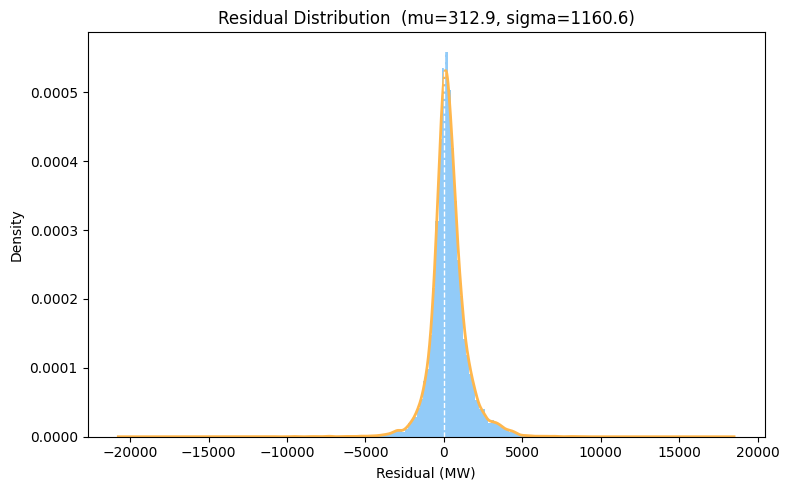

In [14]:
# ── Residual distribution ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(residuals, bins=100, color=C_BLUE, alpha=0.7, density=True)
pd.Series(residuals).plot.kde(ax=ax, color=C_ORANGE, lw=2)
ax.axvline(0, color='white', lw=1, ls='--')
ax.set_title(f'Residual Distribution  (mu={residuals.mean():.1f}, sigma={residuals.std():.1f})')
ax.set_xlabel('Residual (MW)')
ax.set_ylabel('Density')
plt.tight_layout()
plt.show()

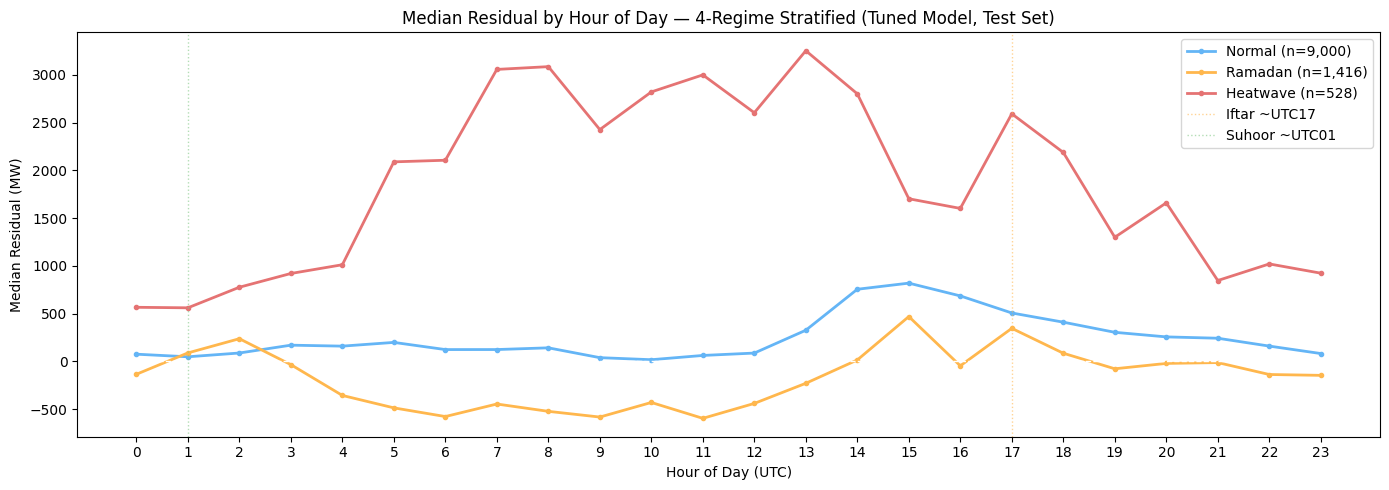

In [15]:
# ── Residual by hour — 4-regime stratified ───────────────────────────────
res_df = pd.DataFrame({
    'residual': residuals,
    'hour':     TEST.index.hour,
    'regime':   TEST['regime'].values,
})

fig, ax = plt.subplots(figsize=(14, 5))
for regime_name, color in REGIME_COLORS.items():
    sub = res_df[res_df['regime'] == regime_name]
    if len(sub) == 0: continue
    grp = sub.groupby('hour')['residual'].median()
    ax.plot(range(24), grp.reindex(range(24)).values,
            color=color, lw=2, label=f'{regime_name} (n={len(sub):,})',
            marker='o', markersize=3)

ax.axhline(0, color='white', lw=1, ls='--')
ax.axvline(17, color=C_ORANGE, ls=':', lw=1, alpha=0.6, label='Iftar ~UTC17')
ax.axvline(1,  color=C_GREEN,  ls=':', lw=1, alpha=0.6, label='Suhoor ~UTC01')
ax.set_title('Median Residual by Hour of Day — 4-Regime Stratified (Tuned Model, Test Set)')
ax.set_xlabel('Hour of Day (UTC)')
ax.set_ylabel('Median Residual (MW)')
ax.set_xticks(range(24))
ax.legend()
plt.tight_layout()
plt.show()

## Regime-Conditional Error Analysis
Stratified across **four operating regimes** (proposal Table 3):  
Normal · Ramadan · Heatwave · Compound (Ramadan ∧ T_max ≥ 35°C).  
All four models reported for a complete ablation picture.


=== A1: No Hijri (default) ===
             N      MAE     RMSE    MAPE    MASE
Regime                                          
Normal    9000   760.60  1141.75  1.9417  0.4585
Ramadan   1416   795.59  1110.37  2.2039  0.4796
Heatwave   528  1716.25  2168.31  3.4417  1.0346
Compound     0      NaN      NaN     NaN     NaN

=== A2: Hijri (default) ===
             N      MAE     RMSE    MAPE    MASE
Regime                                          
Normal    9000   759.30  1134.52  1.9323  0.4577
Ramadan   1416   715.98   961.29  1.9454  0.4316
Heatwave   528  1719.28  2124.09  3.5216  1.0364
Compound     0      NaN      NaN     NaN     NaN

=== B:  Hijri + HW-inter ===
             N      MAE     RMSE    MAPE    MASE
Regime                                          
Normal    9000   763.71  1133.74  1.9402  0.4604
Ramadan   1416   711.17   951.36  1.9339  0.4287
Heatwave   528  1756.88  2202.74  3.5485  1.0590
Compound     0      NaN      NaN     NaN     NaN

=== Tuned (Hijri + HW, Opt

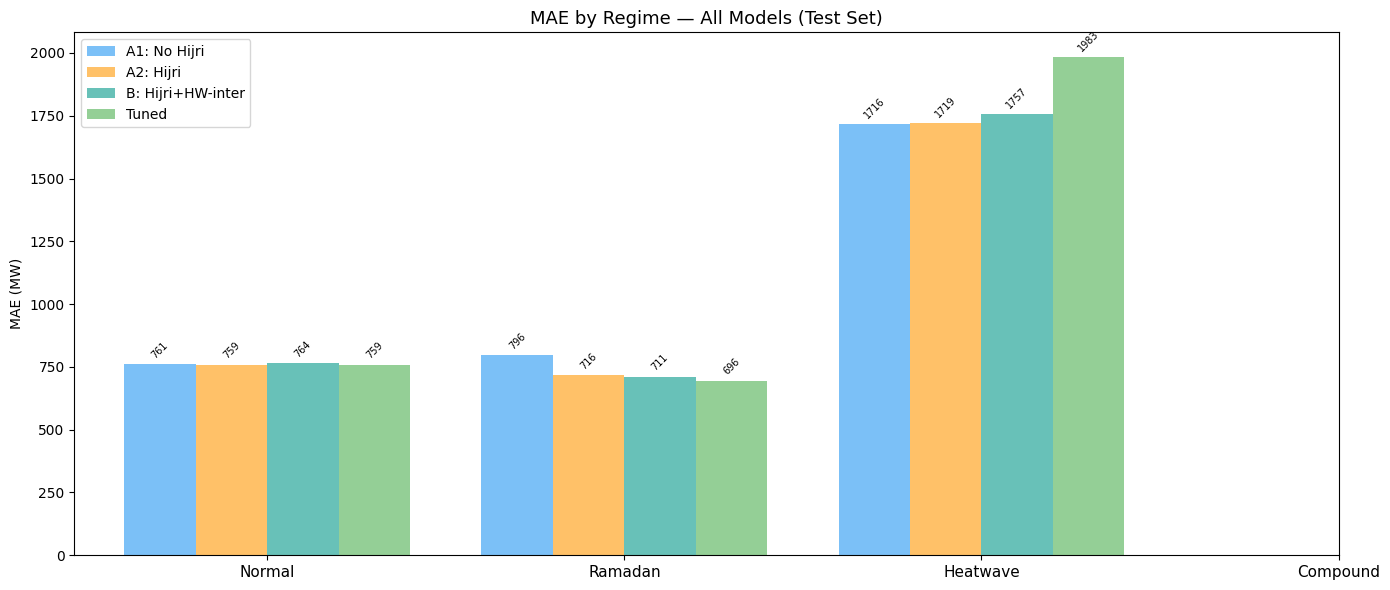

In [16]:
regimes_test = TEST['regime'].values

regime_metrics_base  = regime_evaluate(y_test.values, pred_base_test,  regimes_test, y_train)
regime_metrics_hijri = regime_evaluate(y_test.values, pred_hijri_test, regimes_test, y_train)
regime_metrics_hw    = regime_evaluate(y_test.values, pred_hw_test,    regimes_test, y_train)
regime_metrics_tuned = regime_evaluate(y_test.values, pred_tuned_test, regimes_test, y_train)

for label, rm in [
    ('A1: No Hijri (default)',      regime_metrics_base),
    ('A2: Hijri (default)',         regime_metrics_hijri),
    ('B:  Hijri + HW-inter',        regime_metrics_hw),
    ('Tuned (Hijri + HW, Optuna)',  regime_metrics_tuned),
]:
    print(f'\n=== {label} ===')
    print(rm.to_string())

# ── MAE bar chart — all 4 models x 4 regimes ─────────────────────────────
regimes_plot = ['Normal', 'Ramadan', 'Heatwave', 'Compound']
x = np.arange(len(regimes_plot))
w = 0.20
model_results = [
    (regime_metrics_base,  'A1: No Hijri',     C_BLUE),
    (regime_metrics_hijri, 'A2: Hijri',         C_ORANGE),
    (regime_metrics_hw,    'B: Hijri+HW-inter', C_TEAL),
    (regime_metrics_tuned, 'Tuned',             C_GREEN),
]

fig, ax = plt.subplots(figsize=(14, 6))
for j, (rm, label, color) in enumerate(model_results):
    vals = [rm.loc[r, 'MAE'] if r in rm.index else np.nan for r in regimes_plot]
    bars = ax.bar(x + (j - 1.5) * w, vals, width=w,
                  color=color, alpha=0.85, label=label)
    for bar, v in zip(bars, vals):
        if not np.isnan(v):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                    f'{v:.0f}', ha='center', va='bottom', fontsize=7, rotation=45)

ax.set_xticks(x)
ax.set_xticklabels(regimes_plot, fontsize=11)
ax.set_title('MAE by Regime — All Models (Test Set)', fontsize=13)
ax.set_ylabel('MAE (MW)')
ax.legend()
plt.tight_layout()
plt.show()

In [17]:
# ── Per-year Ramadan & Compound error — all 4 models ─────────────────────
print('=== Ramadan & Compound MAE per year — Test: 2024-2025 ===')

res_full = pd.DataFrame({
    'actual':     y_test.values,
    'pred_base':  pred_base_test,
    'pred_hijri': pred_hijri_test,
    'pred_hw':    pred_hw_test,
    'pred_tuned': pred_tuned_test,
    'regime':     TEST['regime'].values,
    'year':       TEST.index.year,
}, index=TEST.index)

for regime_name in ['Ramadan', 'Compound']:
    print(f'\n  -- {regime_name} --')
    for year in sorted(res_full['year'].unique()):
        sub = res_full[(res_full['year'] == year) & (res_full['regime'] == regime_name)]
        if len(sub) == 0:
            print(f'    {year}: no {regime_name} hours in test set')
            continue
        mae_b = mean_absolute_error(sub['actual'], sub['pred_base'])
        mae_h = mean_absolute_error(sub['actual'], sub['pred_hijri'])
        mae_w = mean_absolute_error(sub['actual'], sub['pred_hw'])
        mae_t = mean_absolute_error(sub['actual'], sub['pred_tuned'])
        print(
            f'    {year} (n={len(sub):,}): '
            f'Base={mae_b:.1f} | Hijri={mae_h:.1f} (d{mae_h-mae_b:+.1f}) | '
            f'HW={mae_w:.1f} (d{mae_w-mae_b:+.1f}) | '
            f'Tuned={mae_t:.1f} (d{mae_t-mae_b:+.1f}) MW'
        )

=== Ramadan & Compound MAE per year — Test: 2024-2025 ===

  -- Ramadan --
    2024 (n=720): Base=738.2 | Hijri=606.0 (d-132.2) | HW=598.9 (d-139.3) | Tuned=584.0 (d-154.2) MW
    2025 (n=696): Base=855.0 | Hijri=829.8 (d-25.2) | HW=827.3 (d-27.7) | Tuned=811.4 (d-43.6) MW

  -- Compound --
    2024: no Compound hours in test set
    2025: no Compound hours in test set


---
## Diebold-Mariano Statistical Tests
Pairwise DM tests (MAE loss, h=24, Newey-West HAC SE).  
Holm-Bonferroni correction applied across all pairs.  
H0: equal predictive accuracy. α = 0.05 (proposal §5).

In [18]:
dm_predictions = {
    'A1: No Hijri':        pred_base_test,
    'A2: Hijri (default)': pred_hijri_test,
    'B: Hijri+HW-inter':   pred_hw_test,
    'Tuned (full)':        pred_tuned_test,
}

dm_results = dm_table(y_test.values, dm_predictions, h=24)
print('=== Diebold-Mariano Test Results (Test Set, MAE loss, h=24) ===')
print(dm_results.to_string(index=False))

# ── Per-regime DM: A1 Base vs Tuned ──────────────────────────────────────
print('\n=== DM test by Regime: A1 Base vs Tuned ===')
regimes_test = TEST['regime'].values
for r in REGIMES:
    mask = regimes_test == r
    if mask.sum() < 30:
        print(f'  {r:<10}: insufficient samples (n={mask.sum()})')
        continue
    dm_stat, p_val = dm_test(
        y_test.values[mask], pred_base_test[mask], pred_tuned_test[mask], h=24
    )
    sig = 'reject H0' if p_val < 0.05 else 'fail to reject'
    print(f'  {r:<10}: DM={dm_stat:+.3f}, p={p_val:.4f}  {sig}  (n={mask.sum():,})')

=== Diebold-Mariano Test Results (Test Set, MAE loss, h=24) ===
            Model A             Model B  DM stat  p-value (raw)  p-value (HB)  Reject H0 (a=0.05)
       A1: No Hijri A2: Hijri (default)    1.489         0.1365        0.8187               False
       A1: No Hijri   B: Hijri+HW-inter    0.908         0.3639        1.0000               False
       A1: No Hijri        Tuned (full)    0.118         0.9062        0.9062               False
A2: Hijri (default)   B: Hijri+HW-inter   -1.136         0.2558        1.0000               False
A2: Hijri (default)        Tuned (full)   -1.408         0.1592        0.7961               False
  B: Hijri+HW-inter        Tuned (full)   -0.816         0.4144        0.8289               False

=== DM test by Regime: A1 Base vs Tuned ===
  Normal    : DM=+0.168, p=0.8665  fail to reject  (n=9,000)
  Ramadan   : DM=+2.677, p=0.0074  reject H0  (n=1,416)
  Heatwave  : DM=-7.324, p=0.0000  reject H0  (n=528)
  Compound  : insufficient samples

---
## Save Predictions — Benchmarking Parquet
Consolidates all four model predictions (val + test) into a single Parquet.  
Includes timestamp index, actuals, 4-regime label, split tag,  
residuals, and APE per model.  
Schema is compatible with all other benchmark notebooks in this study.

In [19]:
def _build_split(split_label, split_df, actuals,
                 pred_base, pred_hijri, pred_hw, pred_tuned):
    df_out = pd.DataFrame({
        'split':              split_label,
        'actual_load_mw':     actuals,
        'regime':             split_df['regime'].values,
        'is_ramadan':         split_df['is_ramadan'].values,
        'is_heatwave':        split_df['is_heatwave'].values,
        'pred_lgbm_base_mw':  pred_base,
        'pred_lgbm_hijri_mw': pred_hijri,
        'pred_lgbm_hw_mw':    pred_hw,
        'pred_lgbm_tuned_mw': pred_tuned,
    }, index=split_df.index)
    # Residuals
    for tag, col in [('base',  'pred_lgbm_base_mw'),
                     ('hijri', 'pred_lgbm_hijri_mw'),
                     ('hw',    'pred_lgbm_hw_mw'),
                     ('tuned', 'pred_lgbm_tuned_mw')]:
        df_out[f'resid_lgbm_{tag}_mw'] = df_out['actual_load_mw'] - df_out[col]
    # Absolute percentage error
    act = df_out['actual_load_mw'].replace(0, pd.NA)
    for tag, col in [('base',  'pred_lgbm_base_mw'),
                     ('hijri', 'pred_lgbm_hijri_mw'),
                     ('hw',    'pred_lgbm_hw_mw'),
                     ('tuned', 'pred_lgbm_tuned_mw')]:
        df_out[f'ape_lgbm_{tag}'] = (df_out['actual_load_mw'] - df_out[col]).abs() / act * 100
    return df_out

val_preds  = _build_split('val',  VAL,  y_val.values,
                           pred_base_val,  pred_hijri_val,  pred_hw_val,  pred_tuned_val)
test_preds = _build_split('test', TEST, y_test.values,
                           pred_base_test, pred_hijri_test, pred_hw_test, pred_tuned_test)

all_preds = pd.concat([val_preds, test_preds]).sort_index()

OUT_PATH = PRED_DIR / 'lgbm_predictions.parquet'
all_preds.to_parquet(OUT_PATH, index=True, engine='pyarrow', compression='snappy')

print(f'Saved   -> {OUT_PATH}')
print(f'Shape   : {all_preds.shape}')
print(f'Splits  : {all_preds["split"].value_counts().to_dict()}')
print(f'Regimes : {all_preds["regime"].value_counts().to_dict()}')
print(f'\nSchema:')
print(all_preds.dtypes.to_string())

Saved   -> C:\Users\dr_sh\OneDrive\Desktop\ElectricityLoadForcasting\predictions\lgbm_predictions.parquet
Shape   : (19704, 17)
Splits  : {'test': 10944, 'val': 8760}
Regimes : {'Normal': 16488, 'Ramadan': 2112, 'Heatwave': 1104}

Schema:
split                   object
actual_load_mw         float64
regime                  object
is_ramadan               int64
is_heatwave              int64
pred_lgbm_base_mw      float64
pred_lgbm_hijri_mw     float64
pred_lgbm_hw_mw        float64
pred_lgbm_tuned_mw     float64
resid_lgbm_base_mw     float64
resid_lgbm_hijri_mw    float64
resid_lgbm_hw_mw       float64
resid_lgbm_tuned_mw    float64
ape_lgbm_base          float64
ape_lgbm_hijri         float64
ape_lgbm_hw            float64
ape_lgbm_tuned         float64


---
## Feature Importance

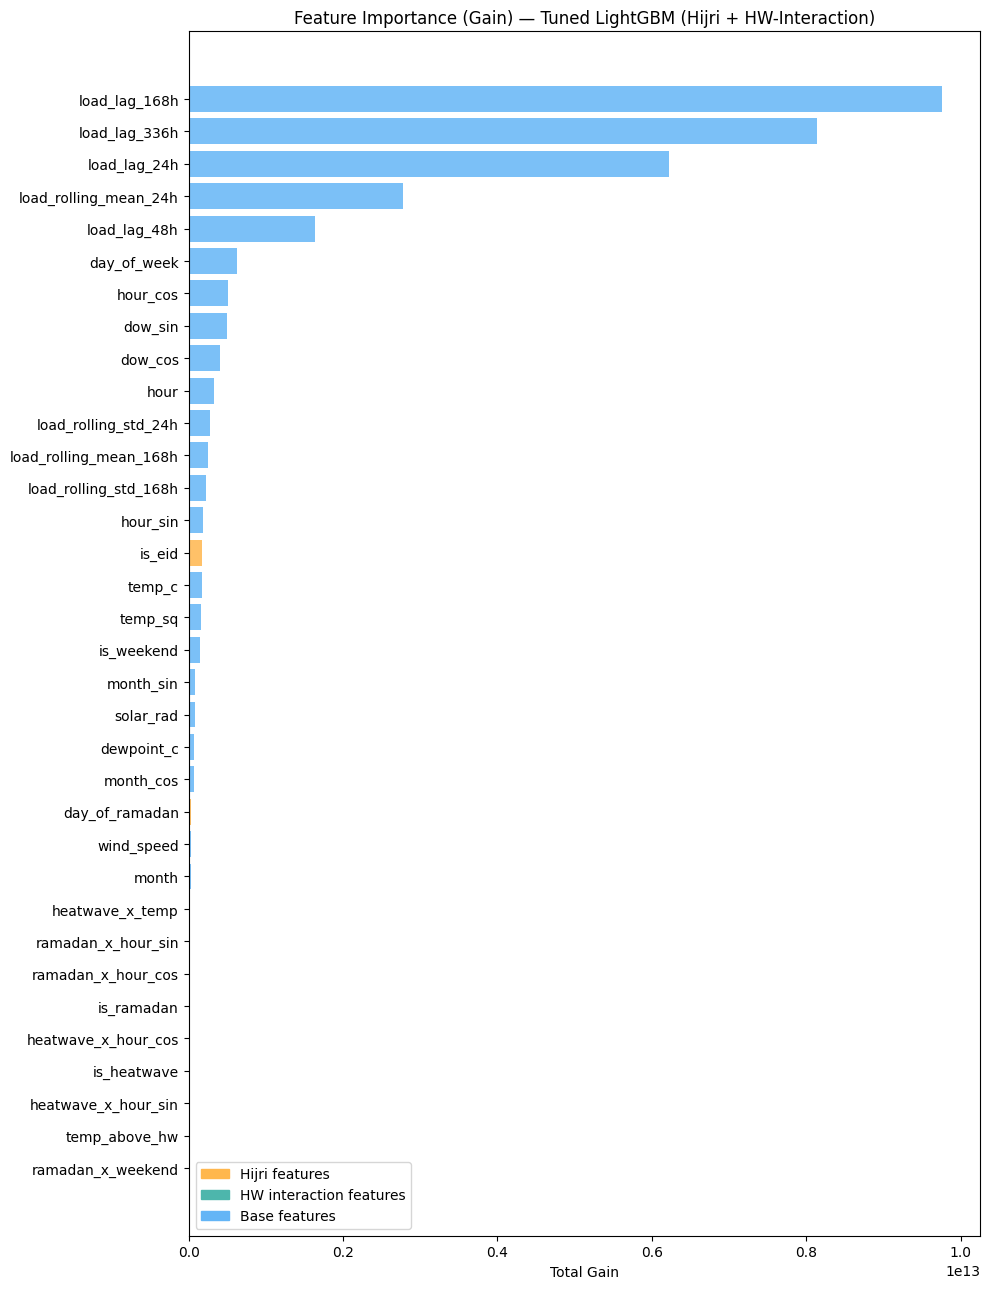


=== Top 15 features by gain ===
load_lag_168h             9.761767e+12
load_lag_336h             8.137050e+12
load_lag_24h              6.217503e+12
load_rolling_mean_24h     2.780387e+12
load_lag_48h              1.632943e+12
day_of_week               6.323121e+11
hour_cos                  5.039442e+11
dow_sin                   4.937994e+11
dow_cos                   4.104342e+11
hour                      3.285641e+11
load_rolling_std_24h      2.737789e+11
load_rolling_mean_168h    2.483148e+11
load_rolling_std_168h     2.202979e+11
hour_sin                  1.858083e+11
is_eid                    1.795777e+11

Hijri features gain share    : 0.7%
HW interaction gain share    : 0.0%
Base features gain share     : 99.3%


In [20]:
imp = pd.Series(
    model_tuned.booster_.feature_importance(importance_type='gain'),
    index=FULL_FEATURES
).sort_values(ascending=True)

def feat_color(f):
    if f in HIJRI_FEATURES:          return C_ORANGE
    if f in HW_INTERACTION_FEATURES: return C_TEAL
    return C_BLUE

colors_imp = [feat_color(f) for f in imp.index]

fig, ax = plt.subplots(figsize=(10, 13))
ax.barh(imp.index, imp.values, color=colors_imp, alpha=0.85)
ax.set_title('Feature Importance (Gain) — Tuned LightGBM (Hijri + HW-Interaction)')
ax.set_xlabel('Total Gain')

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color=C_ORANGE, label='Hijri features'),
    Patch(color=C_TEAL,   label='HW interaction features'),
    Patch(color=C_BLUE,   label='Base features'),
])
plt.tight_layout()
plt.show()

print('\n=== Top 15 features by gain ===')
print(imp.sort_values(ascending=False).head(15).round(0).to_string())

# Gain share by group
hijri_gain = imp[imp.index.isin(HIJRI_FEATURES)].sum()
hw_gain    = imp[imp.index.isin(HW_INTERACTION_FEATURES)].sum()
total_gain = imp.sum()
print(f'\nHijri features gain share    : {hijri_gain/total_gain*100:.1f}%')
print(f'HW interaction gain share    : {hw_gain/total_gain*100:.1f}%')
print(f'Base features gain share     : {(total_gain-hijri_gain-hw_gain)/total_gain*100:.1f}%')